In [1]:
import torch
import torch.nn as nn
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from transformers import ViTForImageClassification, ViTConfig, ViTFeatureExtractor
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import os
from tqdm import tqdm
from datetime import datetime
import ssl
from PIL import Image

c:\Users\Administrator\Desktop\vit\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## train

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
ssl._create_default_https_context = ssl._create_unverified_context

Using device: cuda


In [ ]:
BATCH_SIZE = 64
IMAGE_SIZE = 224
NUM_EPOCHS = 5
LEARNING_RATE = 2e-5
NUM_CLASSES = len(os.listdir("images/train_images"))
MODEL_SAVE_PATH = "models/vit_model.pth"

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    # transforms.RandomHorizontalFlip(),
    # transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load datasets
train_dataset = datasets.ImageFolder("images/train_images", transform=train_transform)
valid_dataset = datasets.ImageFolder("images/val_images", transform=val_test_transform)
test_dataset = datasets.ImageFolder("images/test_images", transform=val_test_transform)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

# Get class names
class_names = train_dataset.classes
print(f"Found {NUM_CLASSES} classes: {class_names}")

Found 4 classes: ['0', '1', '2', '3']


In [ ]:
# Initialize Vision Transformer model
config = ViTConfig(
    image_size=IMAGE_SIZE,
    num_labels=NUM_CLASSES,
    num_hidden_layers=6,  # Smaller than default for efficiency
    num_attention_heads=8,
    hidden_size=192,
    intermediate_size=768
)

model = ViTForImageClassification.from_pretrained(
    'google/vit-base-patch16-224-in21k',
    num_labels=NUM_CLASSES,  
    ignore_mismatched_sizes=True  
)
model.to(device)

optimizer = torch.optim.AdamW([
    {'params': model.vit.parameters(), 'lr': LEARNING_RATE * 0.1},  
    {'params': model.classifier.parameters(), 'lr': LEARNING_RATE} 
])

criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)


Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [6]:
# Training and validation loop
def train_model():
    train_loss_history = []
    val_loss_history = []
    best_val_loss = float('inf')
    
    for epoch in range(NUM_EPOCHS):
        model.train()
        running_loss = 0.0
        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")
        
        for images, labels in progress_bar:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs.logits, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * images.size(0)
            progress_bar.set_postfix({'loss': loss.item()})
        
        scheduler.step()
        
        # Calculate training loss
        epoch_train_loss = running_loss / len(train_loader.dataset)
        train_loss_history.append(epoch_train_loss)
        
        # Validation
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for images, labels in valid_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs.logits, labels)
                val_loss += loss.item() * images.size(0)
                
                _, predicted = torch.max(outputs.logits.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        epoch_val_loss = val_loss / len(valid_loader.dataset)
        val_loss_history.append(epoch_val_loss)
        val_accuracy = 100 * correct / total
        
        print(f"Epoch {epoch+1}: Train Loss: {epoch_train_loss:.4f}, Val Loss: {epoch_val_loss:.4f}, Val Acc: {val_accuracy:.2f}%")
        
        # Save best model
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            torch.save(model.state_dict(), MODEL_SAVE_PATH)
            print(f"Saved new best model with val loss: {best_val_loss:.4f}")
    return train_loss_history, val_loss_history

In [ ]:
train_loss, val_loss = train_model()

Epoch 1/5: 100%|██████████| 282/282 [10:37<00:00,  2.26s/it, loss=0.666]


Epoch 1: Train Loss: 1.0009, Val Loss: 0.6440, Val Acc: 87.61%
Saved new best model with val loss: 0.6440


Epoch 2/5: 100%|██████████| 282/282 [10:09<00:00,  2.16s/it, loss=0.543]


Epoch 2: Train Loss: 0.4864, Val Loss: 0.3579, Val Acc: 92.31%
Saved new best model with val loss: 0.3579


Epoch 3/5: 100%|██████████| 282/282 [10:07<00:00,  2.15s/it, loss=0.34] 


Epoch 3: Train Loss: 0.3234, Val Loss: 0.2702, Val Acc: 93.61%
Saved new best model with val loss: 0.2702


Epoch 4/5: 100%|██████████| 282/282 [10:11<00:00,  2.17s/it, loss=0.207]


Epoch 4: Train Loss: 0.2634, Val Loss: 0.2399, Val Acc: 94.41%
Saved new best model with val loss: 0.2399


Epoch 5/5: 100%|██████████| 282/282 [07:56<00:00,  1.69s/it, loss=0.198]


Epoch 5: Train Loss: 0.2422, Val Loss: 0.2342, Val Acc: 94.21%
Saved new best model with val loss: 0.2342


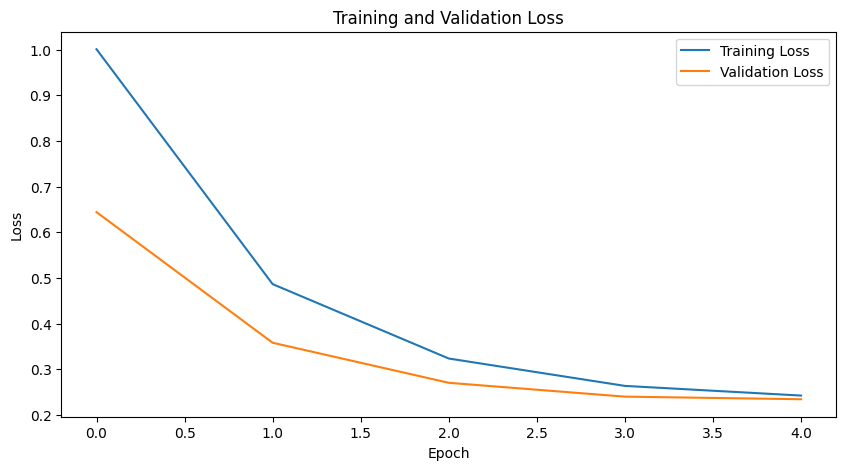

In [8]:
# Plot loss history
plt.figure(figsize=(10, 5))
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.savefig('loss_curve.png')
plt.show()

In [9]:
# Load best model for testing
model.load_state_dict(torch.load(MODEL_SAVE_PATH))
model.eval()

ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermed

In [10]:
all_labels = []
all_preds = []
test_loss = 0.0
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs.logits, labels)
        test_loss += loss.item() * images.size(0)
        
        _, predicted = torch.max(outputs.logits.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())

test_loss = test_loss / len(test_loader.dataset)
test_accuracy = 100 * correct / total

In [11]:
print(f"\nTest Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%")


Test Loss: 0.2716, Test Accuracy: 91.20%


In [12]:
# Classification report
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))


Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.84      0.89       250
           1       0.96      0.91      0.93       250
           2       0.83      0.94      0.88       250
           3       0.92      0.95      0.94       250

    accuracy                           0.91      1000
   macro avg       0.92      0.91      0.91      1000
weighted avg       0.92      0.91      0.91      1000



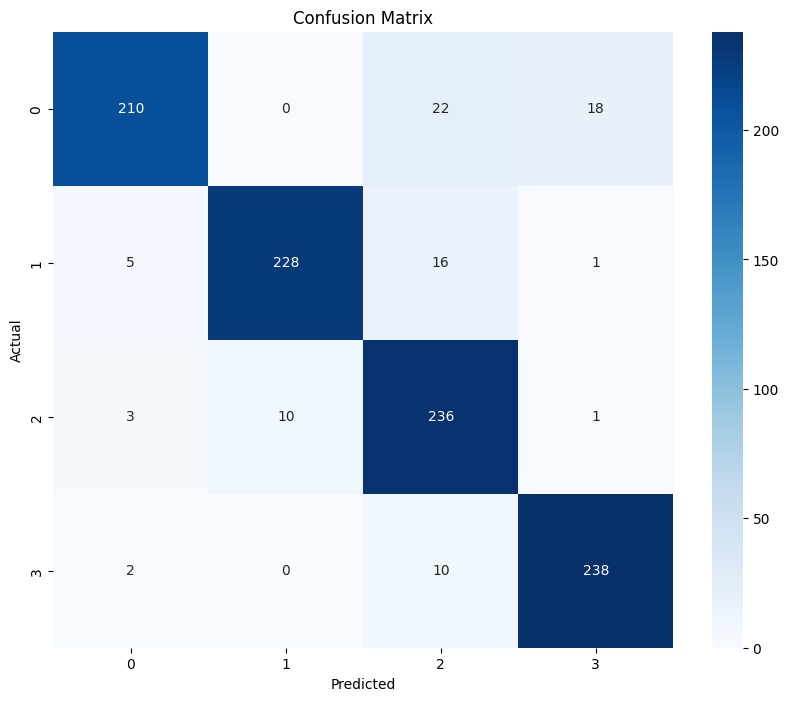

In [13]:
# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('confusion_matrix.png')
plt.show()

In [14]:
# Save evaluation metrics
with open("evaluation_results.txt", "w") as f:
    f.write(f"Evaluation Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"Test Loss: {test_loss:.4f}\n")
    f.write(f"Test Accuracy: {test_accuracy:.2f}%\n")
    f.write("\nTraining Loss History:\n")
    f.write("\n".join([f"Epoch {i+1}: {loss:.4f}" for i, loss in enumerate(train_loss)]))
    f.write("\n\nValidation Loss History:\n")
    f.write("\n".join([f"Epoch {i+1}: {loss:.4f}" for i, loss in enumerate(val_loss)]))

## test

In [3]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Parameters
BATCH_SIZE = 64
IMAGE_SIZE = 224  # ViT typically uses 224x224 images
NUM_EPOCHS = 5
LEARNING_RATE = 2e-5
NUM_CLASSES = len(os.listdir("images/train_images"))  # Automatically detect number of classes
MODEL_SAVE_PATH = "models/vit_model.pth"

val_test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_dataset = datasets.ImageFolder("images/test_images", transform=val_test_transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

# Get class names
class_names = test_dataset.classes
print(f"Found {NUM_CLASSES} classes: {class_names}")

Using device: cuda
Found 4 classes: ['0', '1', '2', '3']


In [ ]:
model = ViTForImageClassification.from_pretrained(
    'google/vit-base-patch16-224-in21k',
    num_labels=NUM_CLASSES,
    ignore_mismatched_sizes=True
)
model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))
model.to(device)
model.eval()

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermed

In [5]:
def evaluate_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Evaluating"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.logits, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    accuracy = 100 * correct / total
    print(f"Test Accuracy: {accuracy:.2f}%")
    return all_labels, all_preds

In [6]:
labels, predictions = evaluate_model(model, test_loader)

Evaluating: 100%|██████████| 25/25 [00:43<00:00,  1.76s/it]

Test Accuracy: 88.94%


              precision    recall  f1-score   support

           0       0.93      0.85      0.89       400
           1       0.90      0.90      0.90       400
           2       0.82      0.90      0.86       400
           3       0.92      0.91      0.91       400

    accuracy                           0.89      1600
   macro avg       0.89      0.89      0.89      1600
weighted avg       0.89      0.89      0.89      1600



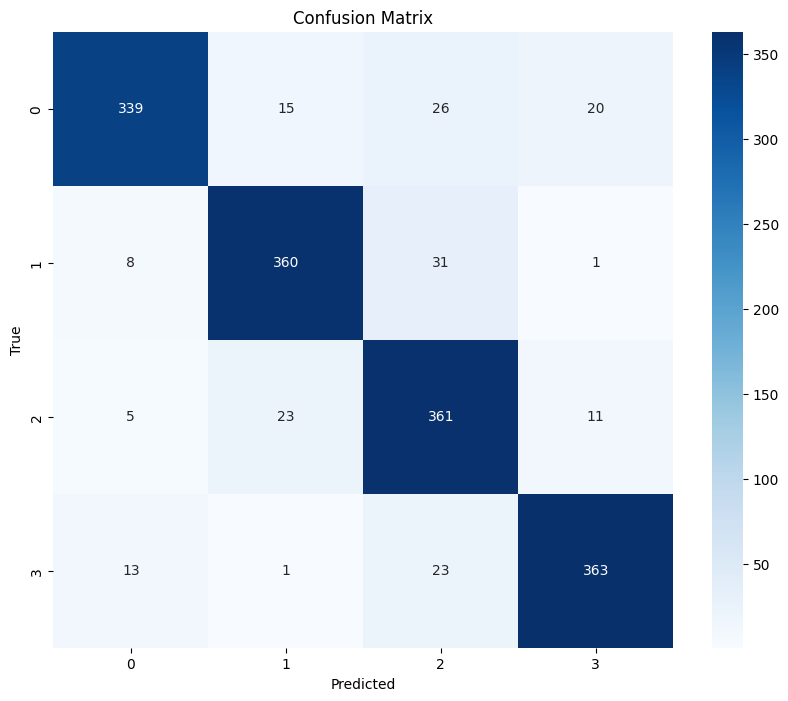

In [ ]:
print(classification_report(labels, predictions, target_names=class_names))

cm = confusion_matrix(labels, predictions)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
labels_list = ['BENIGN', 'Group1' , 'Group2', "Syn"]

def predict_image(image_path):
    image = Image.open(image_path).convert('RGB')
    transform = transforms.Compose([
        transforms.Resize((224, 224)),  # Kích thước chuẩn của ViT
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])
    image_tensor = transform(image).unsqueeze(0).to(device)  # Thêm batch dimension

    model.eval()
    with torch.no_grad():
        outputs = model(image_tensor)
        _, predicted = torch.max(outputs.logits, 1)
    return labels_list[predicted.item()]


def predict_many_images(label, folder_path):
    all_file_paths = []
    for root, dirs, files in os.walk(folder_path):
        for file in files:
            full_path = os.path.join(root, file)
            all_file_paths.append(full_path)

    # print(len(all_file_paths))
    name_details_dict = {}

    for j in all_file_paths:
        r = predict_image(f"{j}")
        if r in name_details_dict:
            name_details_dict[r] += 1
        else:
            name_details_dict[r] = 1

    print(f'Label: {label}', name_details_dict)

In [19]:
predict_many_images('Benign', 'test/images/benign')
predict_many_images('Syn', 'test/images/syn')
predict_many_images('Udp', 'test/images/udp')

Label: Benign {'BENIGN': 1806, 'Group2': 104, 'Syn': 42, 'Group1': 48}
Label: Syn {'Syn': 1891, 'Group2': 74, 'BENIGN': 35}
Label: Udp {'Group2': 2903, 'BENIGN': 24, 'Group1': 9}
